In [1]:
import pandas as pd

df = pd.read_csv("../data/students_survey.csv")

In [103]:
df.columns

Index(['Specialty', 'Education year', 'Form', 'Employement',
       'Financial Satisfaction', 'Access to social services',
       'Access to research resources and infrastructure',
       'Regular meetings with supervisor',
       'Satisfaction with supervision meetings',
       'Clarity of supervision guidance',
       'Supervisor support for research progress',
       'Supervisor accessibility and availability',
       'Overall supervision satisfaction', 'Well_being'],
      dtype='object')

In [4]:
df = df.rename(columns={'Təhsil dövründə iş–şəxsi həyatımda balans mövcuddur': 'Well_being'}) 

In [36]:
df = df.rename(columns={'Tədqiqat resurslarına və infrastrukturuna çıxış imkanlarınızı 1-dən 10-a qədər qiymətləndirin\n': 'Access to research resources and infrastructure'}) 

In [37]:
df = df.rename(columns={'Psixoloji və sosial dəstək xidmətlərinin əlçatanlığını necə qiymətləndirirsiniz?': 'Access to social services'}) 

In [67]:
df = df.rename(columns={'FinancialSatisfaction': 'Financial Satisfaction'}) 

In [86]:
df = df.rename(columns={'Supervisor_meeting': 'Regular meetings with supervisor'}) 

In [100]:
df = df.rename(columns={'Supervisor_satisfaction': 'Overall supervision satisfaction'})

In [70]:
df = df.rename(columns={'Clearity_supervisor': 'Clarity of supervision guidance'})

In [71]:
df = df.rename(columns={'Supervisor_access': 'Supervisor accessibility and availability'})

In [102]:
df = df.rename(columns={'supervising_progress': 'Supervisor support for research progress'})

In [38]:
cols = ['FinancialSatisfaction', 'Well_being']

df_cluster = df[cols].dropna()

In [39]:
df_cluster

,FinancialSatisfaction,Well_being
0,4,4
1,3,0
2,4,4
3,2,4
4,0,4
...,...,...
295,3,2
296,2,4
297,3,0
298,3,2


In [40]:
financial_map = {
    "Heç razı deyiləm": 0,
    "Qismən razı deyiləm": 1,
    "Cavab verməkdə çətinlik çəkirəm": 2,
    "Qismən razıyam": 3,
    "Xeyli razıyam": 4
}

support_map = {
    "Çox zəif": 0,
    "Zəif": 1,
    "Orta": 2,
    "Yaxşı": 3,
    "Əla": 4
}

"""supervisor_map = {
    "Heç razı deyiləm": 0,
    "Qismən razı deyiləm": 1,
    "Cavab verməkdə çətinlik çəkirəm": 2,
    "Qismən razıyam": 3,
    "Xeyli razıyam": 4
}"""
df_cluster['Well_being'] = df_cluster['Well_being'].map(financial_map)
#df_cluster['Support_access'] = df_cluster['Support_access'].map(support_map)
df_cluster['FinancialSatisfaction'] = df_cluster['FinancialSatisfaction'].map(financial_map)
#df_cluster = df_cluster.dropna()

In [41]:
df_cluster = df_cluster[cols].dropna()

In [42]:
df_cluster.isna().any().any()

False

In [43]:
df_cluster.shape

(0, 2)

In [44]:
df_cluster.head()

,FinancialSatisfaction,Well_being


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required by StandardScaler.

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

In [ ]:
labels = kmeans.fit_predict(X_scaled)

In [ ]:
df_cluster.shape

In [46]:
X_scaled.shape

(100, 2)

In [47]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print(score)

0.761056906379546


In [48]:
df_cluster['Cluster'] = labels

In [49]:
df_cluster.groupby('Cluster').mean()

,FinancialSatisfaction,Well_being
Cluster,,
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


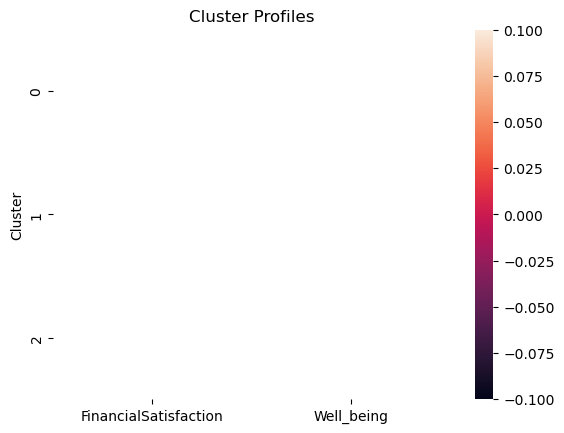

In [50]:
import seaborn as sns

sns.heatmap(
    df_cluster.groupby('Cluster').mean(),
    annot=True
)

plt.title("Cluster Profiles")
plt.show()

In [51]:
sns.countplot(
    x='FinanciaSatisfaction',
    hue='Cluster',
    data=df_cluster
)
plt.show()

ValueError: Could not interpret value `FinanciaSatisfaction` for `x`. An entry with this name does not appear in `data`.

In [52]:
df

,Specialty,Education year,Form,Employement,FinancialSatisfaction,Access to social services,Access to research resources and infrastructure,Supervisor_meeting,Quality_supervisor,Clearity_supervisor,supervising_progress,Supervisor_access,Supervisor_satisfaction,Well_being
0,15,1.0,0,10,4,1,9.0,1,4,4,4,5,3,4
1,15,3.0,1,16,3,2,7.0,3,0,3,2,2,1,0
2,15,1.0,1,16,4,1,10.0,0,4,4,4,1,3,4
3,0,3.0,0,22,2,0,7.0,0,2,2,4,1,3,4
4,14,1.0,0,16,0,0,10.0,1,4,4,4,5,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,5,2.0,0,22,3,0,9.0,0,4,4,4,1,3,2
296,7,4.0,1,26,2,5,8.0,0,4,4,4,5,3,4
297,14,2.0,1,0,3,0,8.0,0,2,2,4,5,3,0
298,14,4.0,1,26,3,0,7.0,1,4,4,4,5,3,2


In [53]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column].astype(str))

print(df.head())

   Specialty  Education year  Form  Employement  FinancialSatisfaction  \
0         15             1.0     0           10                      4   
1         15             3.0     1           16                      3   
2         15             1.0     1           16                      4   
3          0             3.0     0           22                      2   
4         14             1.0     0           16                      0   

   Access to social services  Access to research resources and infrastructure  \
0                          1                                              9.0   
1                          2                                              7.0   
2                          1                                             10.0   
3                          0                                              7.0   
4                          0                                             10.0   

   Supervisor_meeting  Quality_supervisor  Clearity_supervisor  \
0 

In [108]:
y = df['Well_being']
X = df.drop(columns=['Well_being'])

In [109]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_encoded = pd.get_dummies(X, drop_first=True)

In [74]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_encoded, y_encoded)

RandomForestClassifier(n_estimators=200, random_state=42)

In [75]:
import pandas as pd

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

                                            feature  importance
0                                         Specialty    0.143468
6   Access to research resources and infrastructure    0.141773
3                                       Employement    0.110794
4                            Financial Satisfaction    0.100560
1                                    Education year    0.085841
5                         Access to social services    0.083701
7                  Regular meetings with supervisor    0.068593
11        Supervisor accessibility and availability    0.056400
8                                Quality_supervisor    0.053810
9                   Clarity of supervision guidance    0.045287


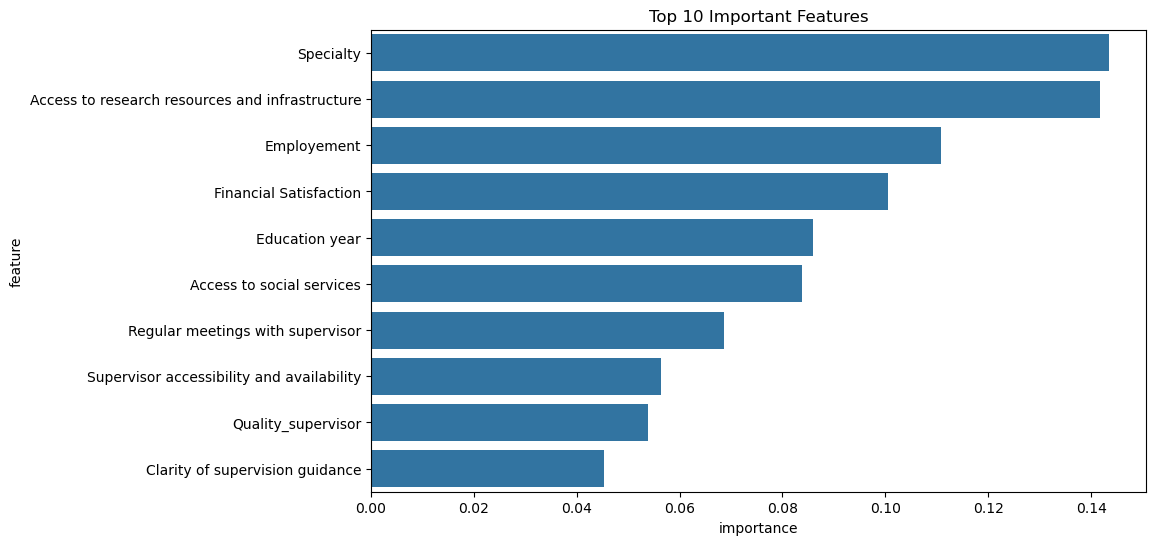

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()


In [77]:
y_pred = model.predict(X_encoded)

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_encoded, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00       108
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        91
           5       1.00      1.00      1.00         6

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



TypeError: can only concatenate str (not "numpy.int32") to str

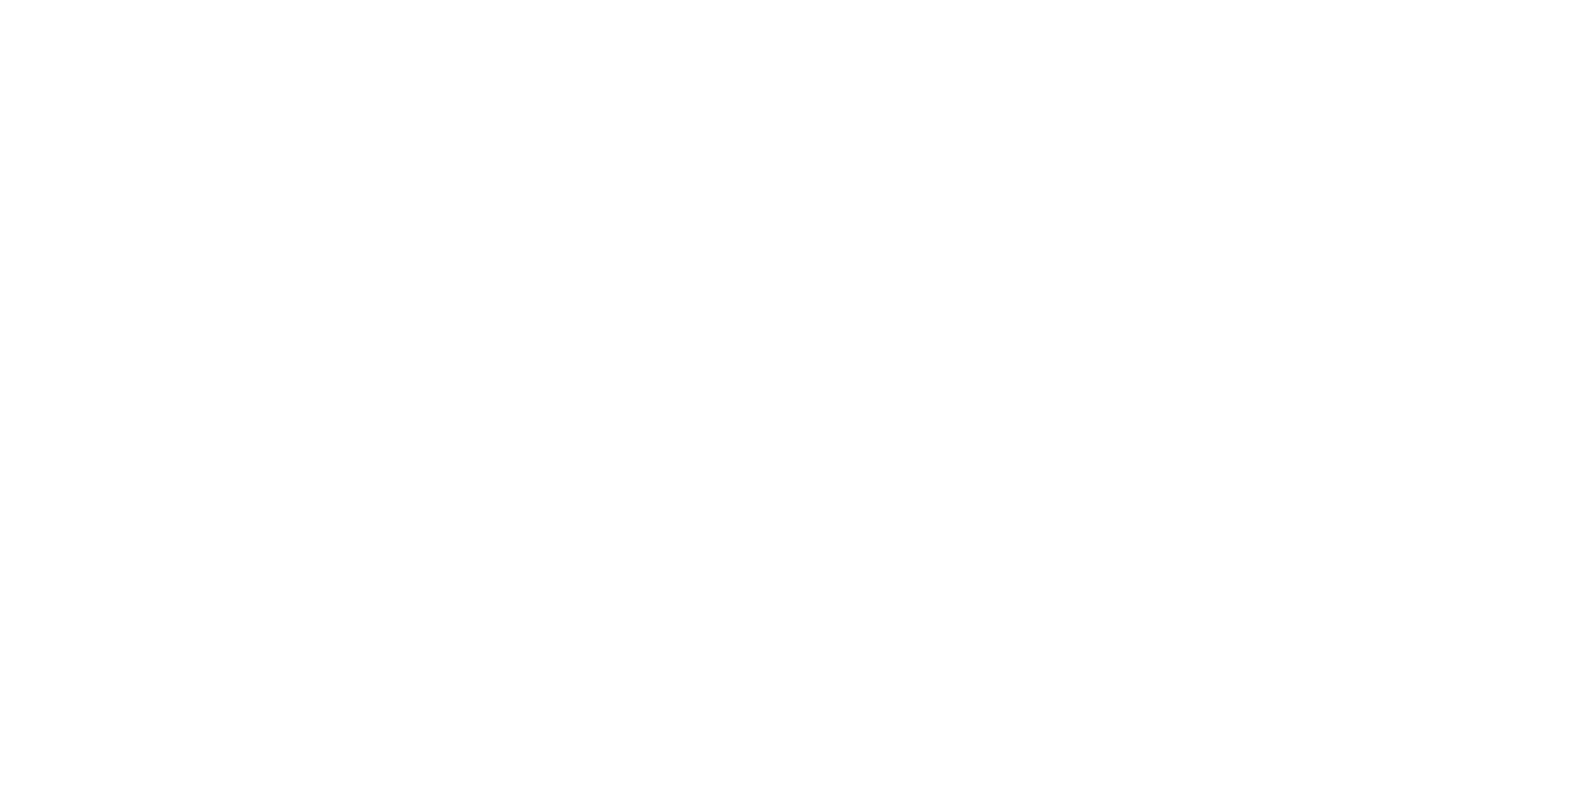

In [79]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select one tree from the forest
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X_encoded.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=2  # limit depth for readability
)

plt.show()

In [110]:
import shap

In [111]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_encoded)

(300, 13, 6)
                                           feature  importance
6  Access to research resources and infrastructure    0.034037
4                           Financial Satisfaction    0.026364
5                        Access to social services    0.023831
0                                        Specialty    0.021843
8           Satisfaction with supervision meetings    0.020783


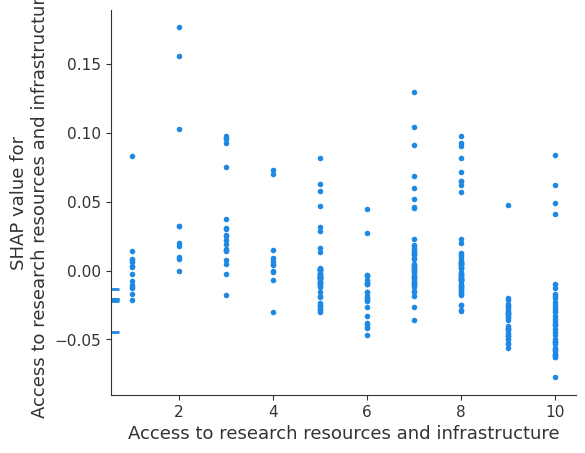

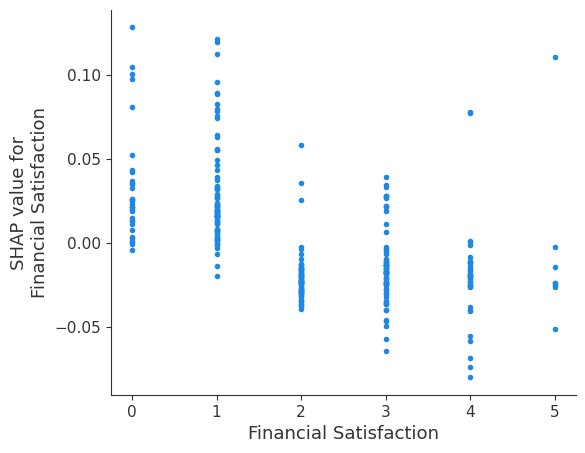

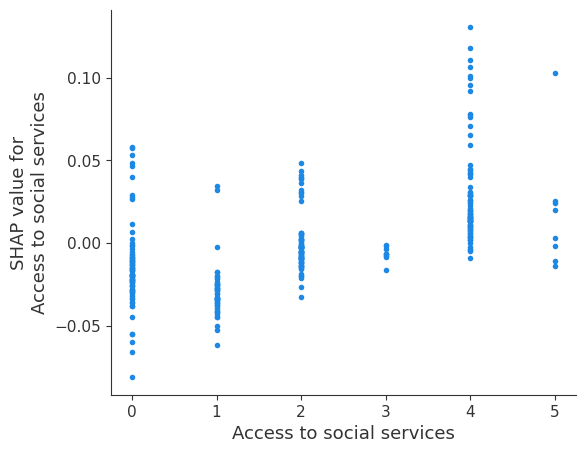

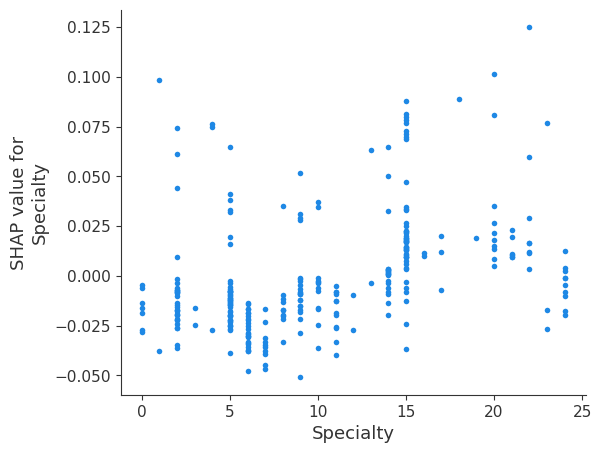

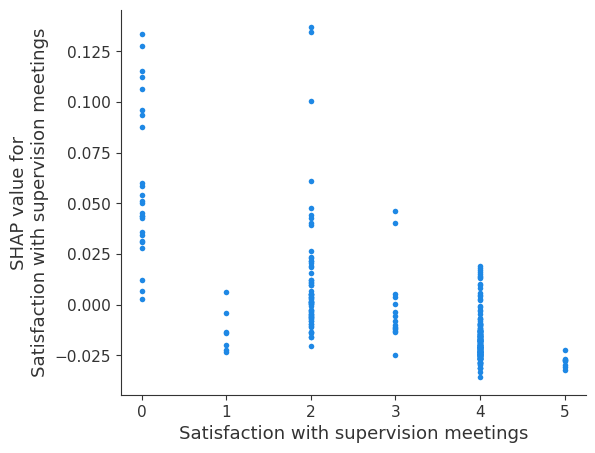

In [112]:
import numpy as np
import pandas as pd

# Check shape
print(shap_values.shape)

# Correct importance (NEW SHAP format)
shap_importance = np.abs(shap_values).mean(axis=(0, 2))

# Create DataFrame
shap_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False)

print(shap_df.head())

# Top features
top_features = shap_df['feature'].head(5)

# Plot
for col in top_features:
    shap.dependence_plot(
        col,
        shap_values[:, :, 0],   # choose one class for visualization
        X_encoded,
        interaction_index=None
    )

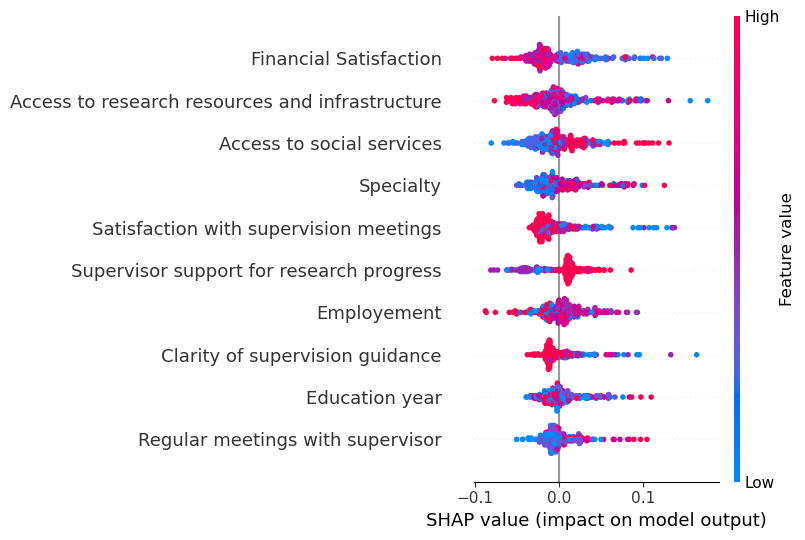

In [113]:
plt.figure(figsize=(14, 8))

shap.summary_plot(
    shap_values[:, :, 0],
    X_encoded,
    max_display=10,
    show=False
)

plt.savefig("../figures/shap_summary.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [93]:
features_to_plot = [
    "Education year",
    "Support_access_Çox zəif",
    "Support_access_Yaxşı"
]

for f in features_to_plot:
    shap.dependence_plot(f, shap_values[0], X_encoded)

IndexError: index 13 is out of bounds for axis 0 with size 13